# Pneumonia Detection Model

This notebook trains a transfer learning model for chest X-ray pneumonia classification using the Kaggle dataset:

`paultimothymooney/chest-xray-pneumonia`

## 1. Install and import dependencies

In [1]:
!pip -q install kagglehub scikit-learn


In [4]:
import os
import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print('TensorFlow:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow: 2.21.0
GPU available: False


E0000 00:00:1778758917.368656   22125 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Reproducibility and configuration

In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

INITIAL_EPOCHS = 8
FINE_TUNE_EPOCHS = 6

MODEL_NAME = 'pneumonia_model'


## 3. Download Kaggle dataset

In [4]:
DATASET_ROOT = Path(kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia'))
print('Dataset root:', DATASET_ROOT)

possible_roots = [
    DATASET_ROOT / 'chest_xray',
    DATASET_ROOT,
    Path('/content/chest_xray'),
]

DATA_DIR = next((p for p in possible_roots if (p / 'train').exists()), None)

if DATA_DIR is None:
    raise FileNotFoundError('Could not find chest_xray/train directory')

TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR = DATA_DIR / 'val'
TEST_DIR = DATA_DIR / 'test'

print('Train:', TRAIN_DIR)
print('Val:', VAL_DIR)
print('Test:', TEST_DIR)

for folder in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print('\n', folder)
    for cls in sorted(os.listdir(folder)):
        cls_path = folder / cls
        if cls_path.is_dir():
            print(cls, len(list(cls_path.glob('*'))))


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset root: /kaggle/input/chest-xray-pneumonia
Train: /kaggle/input/chest-xray-pneumonia/chest_xray/train
Val: /kaggle/input/chest-xray-pneumonia/chest_xray/val
Test: /kaggle/input/chest-xray-pneumonia/chest_xray/test

 /kaggle/input/chest-xray-pneumonia/chest_xray/train
NORMAL 1341
PNEUMONIA 3875

 /kaggle/input/chest-xray-pneumonia/chest_xray/val
NORMAL 8
PNEUMONIA 8

 /kaggle/input/chest-xray-pneumonia/chest_xray/test
NORMAL 234
PNEUMONIA 390


## 4. Data generators

We use `preprocess_input` from DenseNet instead of simple `/255` because the model was pretrained with this preprocessing.

In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    shear_range=0.05,
    horizontal_flip=False,
    fill_mode='nearest'
)

eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=SEED
)

val_generator = eval_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

class_indices = train_generator.class_indices
print('Class indices:', class_indices)

with open('class_indices.json', 'w') as f:
    json.dump(class_indices, f, indent=4)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


## 5. Handle class imbalance

In [6]:
classes = np.unique(train_generator.classes)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)

class_weights = {int(cls): float(weight) for cls, weight in zip(classes, weights)}
print('Class weights:', class_weights)


Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


## 6. Build transfer learning model

In [ ]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)


'''
# same thing:

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
'''


model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,304,257 (27.86 MB)

 Trainable params: 264,705 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

## 7. Train classifier head

In [ ]:
callbacks = [

    # Save the best model during training
    ModelCheckpoint(
        f'{MODEL_NAME}_best.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),

    # Stop training early if validation performance stops improving
    EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history_1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 813ms/step - accuracy: 0.8773 - auc: 0.9504 - loss: 0.2635 - precision: 0.9608 - recall: 0.8712
Epoch 1: val_auc improved from None to 1.00000, saving model to pneumonia_model_best.keras

Epoch 1: finished saving model to pneumonia_model_best.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 184s 930ms/step - accuracy: 0.9195 - auc: 0.9785 - loss: 0.1846 - precision: 0.9766 - recall: 0.9135 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.1186 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.9469 - auc: 0.9904 - loss: 0.1188 - precision: 0.9868 - recall: 0.9413
Epoch 2: val_auc did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 659ms/step - accuracy: 0.9488 - auc: 0.9892 - loss: 0.1249 - precision: 0.9860 - recall: 0.9445 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.1060 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3

## 8. Fine-tune last layers

In [9]:
base_model.trainable = True

# Keep most layers frozen and fine-tune only the last part.
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

history_2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - accuracy: 0.9455 - auc: 0.9856 - loss: 0.1568 - precision: 0.9773 - recall: 0.9487
Epoch 1: val_auc did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 157s 734ms/step - accuracy: 0.9473 - auc: 0.9866 - loss: 0.1433 - precision: 0.9818 - recall: 0.9466 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1131 - val_precision: 1.0000 - val_recall: 0.8750 - learning_rate: 1.0000e-05
Epoch 2/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.9517 - auc: 0.9889 - loss: 0.1270 - precision: 0.9856 - recall: 0.9493
Epoch 2: val_auc did not improve from 1.00000

Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 649ms/step - accuracy: 0.9502 - auc: 0.9895 - loss: 0.1248 - precision: 0.9852 - recall: 0.9471 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1091 - val_precision: 1.0000 - val_recall: 0.8750 - learning_rate: 1.0000e-05
Epoch 3/6
163/163 ━━━━━━━━━━

## 9. Plot training curves

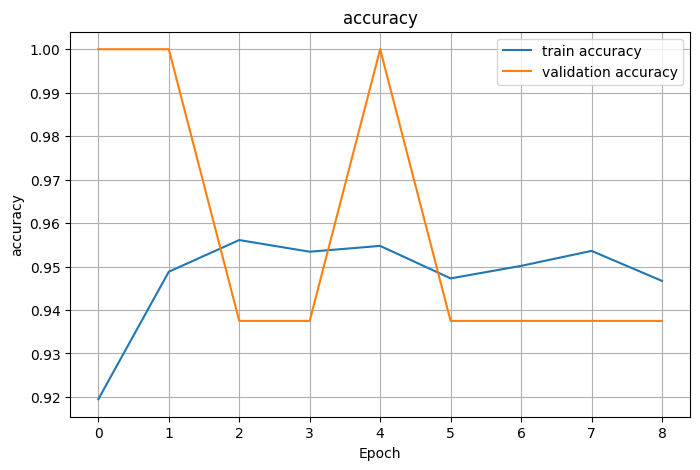

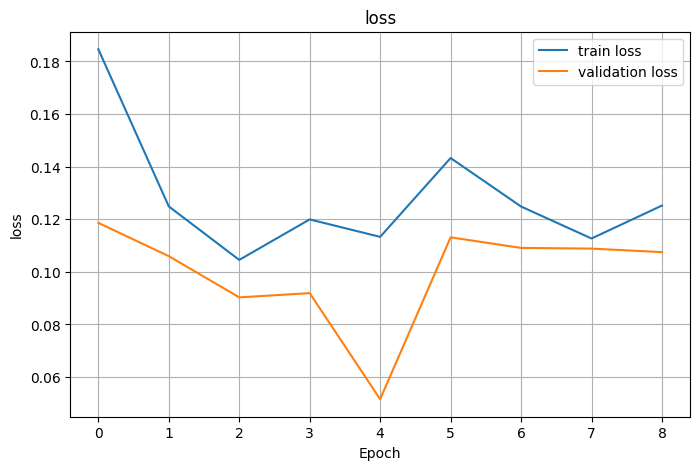

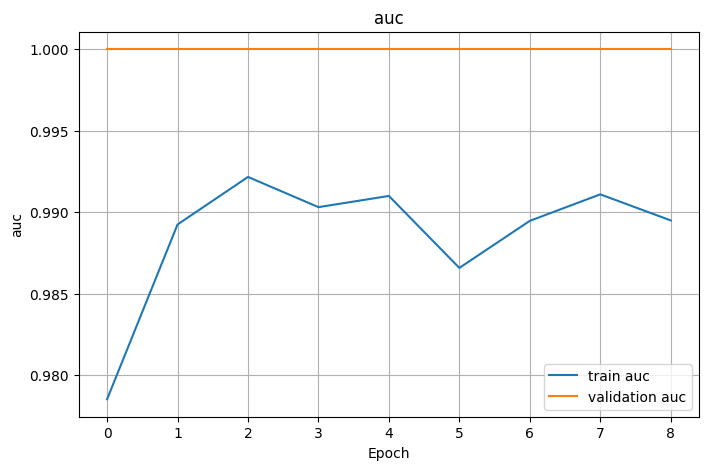

In [10]:
def merge_histories(*histories):
    merged = {}
    for hist in histories:
        for key, values in hist.history.items():
            merged.setdefault(key, []).extend(values)
    return merged

history = merge_histories(history_1, history_2)

with open('training_history.json', 'w') as f:
    json.dump({k: [float(x) for x in v] for k, v in history.items()}, f, indent=4)

def plot_metric(metric):
    plt.figure(figsize=(8, 5))
    plt.plot(history[metric], label=f'train {metric}')
    val_metric = f'val_{metric}'
    if val_metric in history:
        plt.plot(history[val_metric], label=f'validation {metric}')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.title(metric)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_metric('accuracy')
plot_metric('loss')
plot_metric('auc')


## 10. Evaluate on test set

20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 376ms/step - accuracy: 0.8878 - auc: 0.9649 - loss: 0.2634 - precision: 0.8756 - recall: 0.9564
{'loss': 0.26343369483947754, 'compile_metrics': 0.8878205418586731}
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 893ms/step
ROC AUC: 0.9650777996931843

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.77      0.84       234
   PNEUMONIA       0.88      0.96      0.91       390

    accuracy                           0.89       624
   macro avg       0.89      0.86      0.88       624
weighted avg       0.89      0.89      0.89       624

Confusion Matrix:
[[181  53]
 [ 17 373]]


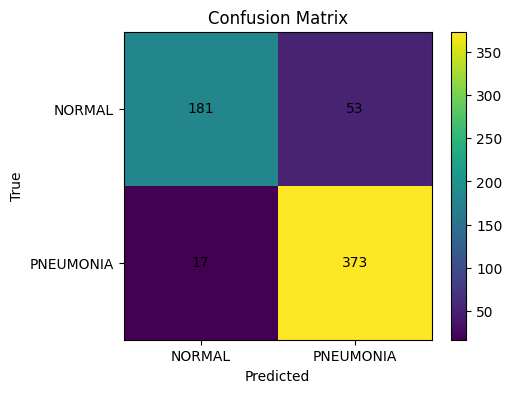

In [11]:
test_results = model.evaluate(test_generator, verbose=1)
print(dict(zip(model.metrics_names, test_results)))

y_true = test_generator.classes
y_prob = model.predict(test_generator).ravel()
y_pred = (y_prob >= 0.5).astype(int)

idx_to_class = {v: k for k, v in class_indices.items()}
target_names = [idx_to_class[i] for i in sorted(idx_to_class)]

print('ROC AUC:', roc_auc_score(y_true, y_prob))
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)
print('Confusion Matrix:')
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.xticks([0, 1], target_names)
plt.yticks([0, 1], target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.colorbar()
plt.show()


## 11. Save model for real project use

In [ ]:
model.save(f'{MODEL_NAME}.keras')
print('Saved:', f'{MODEL_NAME}.keras')

# save a TensorFlow SavedModel export
model.export(f'{MODEL_NAME}_savedmodel')
print('Exported SavedModel folder:', f'{MODEL_NAME}_savedmodel')


Saved: pneumonia_model.keras
Saved artifact at 'pneumonia_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_427')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132838932129808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132838932131152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132838932127888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132838932130384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132838932130768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132838932131728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132838932129616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132838932132112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132838932131344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132838932132688: TensorSpec(shape=(), dty

## 12. Convert to TensorFlow Lite

In [13]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open(f'{MODEL_NAME}.tflite', 'wb') as f:
    f.write(tflite_model)

print('Saved:', f'{MODEL_NAME}.tflite')
print('TFLite size MB:', len(tflite_model) / (1024 * 1024))


Saved artifact at '/tmp/tmpfktt9grs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_427')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132838932129808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132838932131152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132838932127888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132838932130384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132838932130768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132838932131728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132838932129616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132838932132112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132838932131344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132838932132688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1328389321

## 13. Test single image prediction

In [12]:
from tensorflow.keras.preprocessing import image

model = tf.keras.models.load_model(f'{MODEL_NAME}.keras')
with open('class_indices.json') as f:
    class_indices = json.load(f)

idx_to_class = {v: k for k, v in class_indices.items()}

def predict_image(image_path, threshold=0.5):
    img = image.load_img(image_path, target_size=IMG_SIZE)
    arr = image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)

    prob = float(model.predict(arr, verbose=0)[0][0])
    pred_idx = int(prob >= threshold)
    label = idx_to_class[pred_idx]

    return {
        'label': label,
        'pneumonia_probability': prob,
        'threshold': threshold
    }



In [14]:
sample_path = '/home/issamsensi/Downloads/IM-0001-0001.jpeg'
print(predict_image(sample_path))

sample_path = '/home/issamsensi/Downloads/person100_bacteria_478.jpeg'
print(predict_image(sample_path))

{'label': 'NORMAL', 'pneumonia_probability': 0.01863805204629898, 'threshold': 0.5}
{'label': 'PNEUMONIA', 'pneumonia_probability': 0.9995309114456177, 'threshold': 0.5}


## 14. Download final files

In [ ]:
from google.colab import files

for file_name in [
    f'{MODEL_NAME}.keras',
    f'{MODEL_NAME}.tflite',
    f'{MODEL_NAME}_best.keras',
    'class_indices.json',
Prediction
PNEUMONIA
High attention
Confidence
100%
Pneumonia probability
100%
Sigmoid output; ≥ 50% maps to class index 1.
Explanation
This is a prototype AI classifier trained on chest X-ray images. The result is probabilistic and can be wrong. Use it only for learning and demonstrations—not for clinical decisions.

Important
This tool is for educational purposes only and must not replace professional medical diagnosis.

How it works
1
Upload a chest X-ray image (JPG/PNG).
2
The backend resizes to 224×224, converts to RGB, and applies DenseNet preprocessing.
3
A sigmoid output gives pneumonia probability; ≥ 0.5 maps to PNEUMONIA.
Notes
This demo is intentionally conservative: it shows probabilities and warns that predictions can be wrong.
    'training_history.json'
]:
    if Path(file_name).exists():
        print('Downloading:', file_name)
        files.download(file_name)
    else:
        print('Missing:', file_name)


Downloading: pneumonia_model.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: pneumonia_model.tflite


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: training_history.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>